<IPython.core.display.Javascript object>


... Target Frame Logged. Compiling 10-Step Academic Grid ...



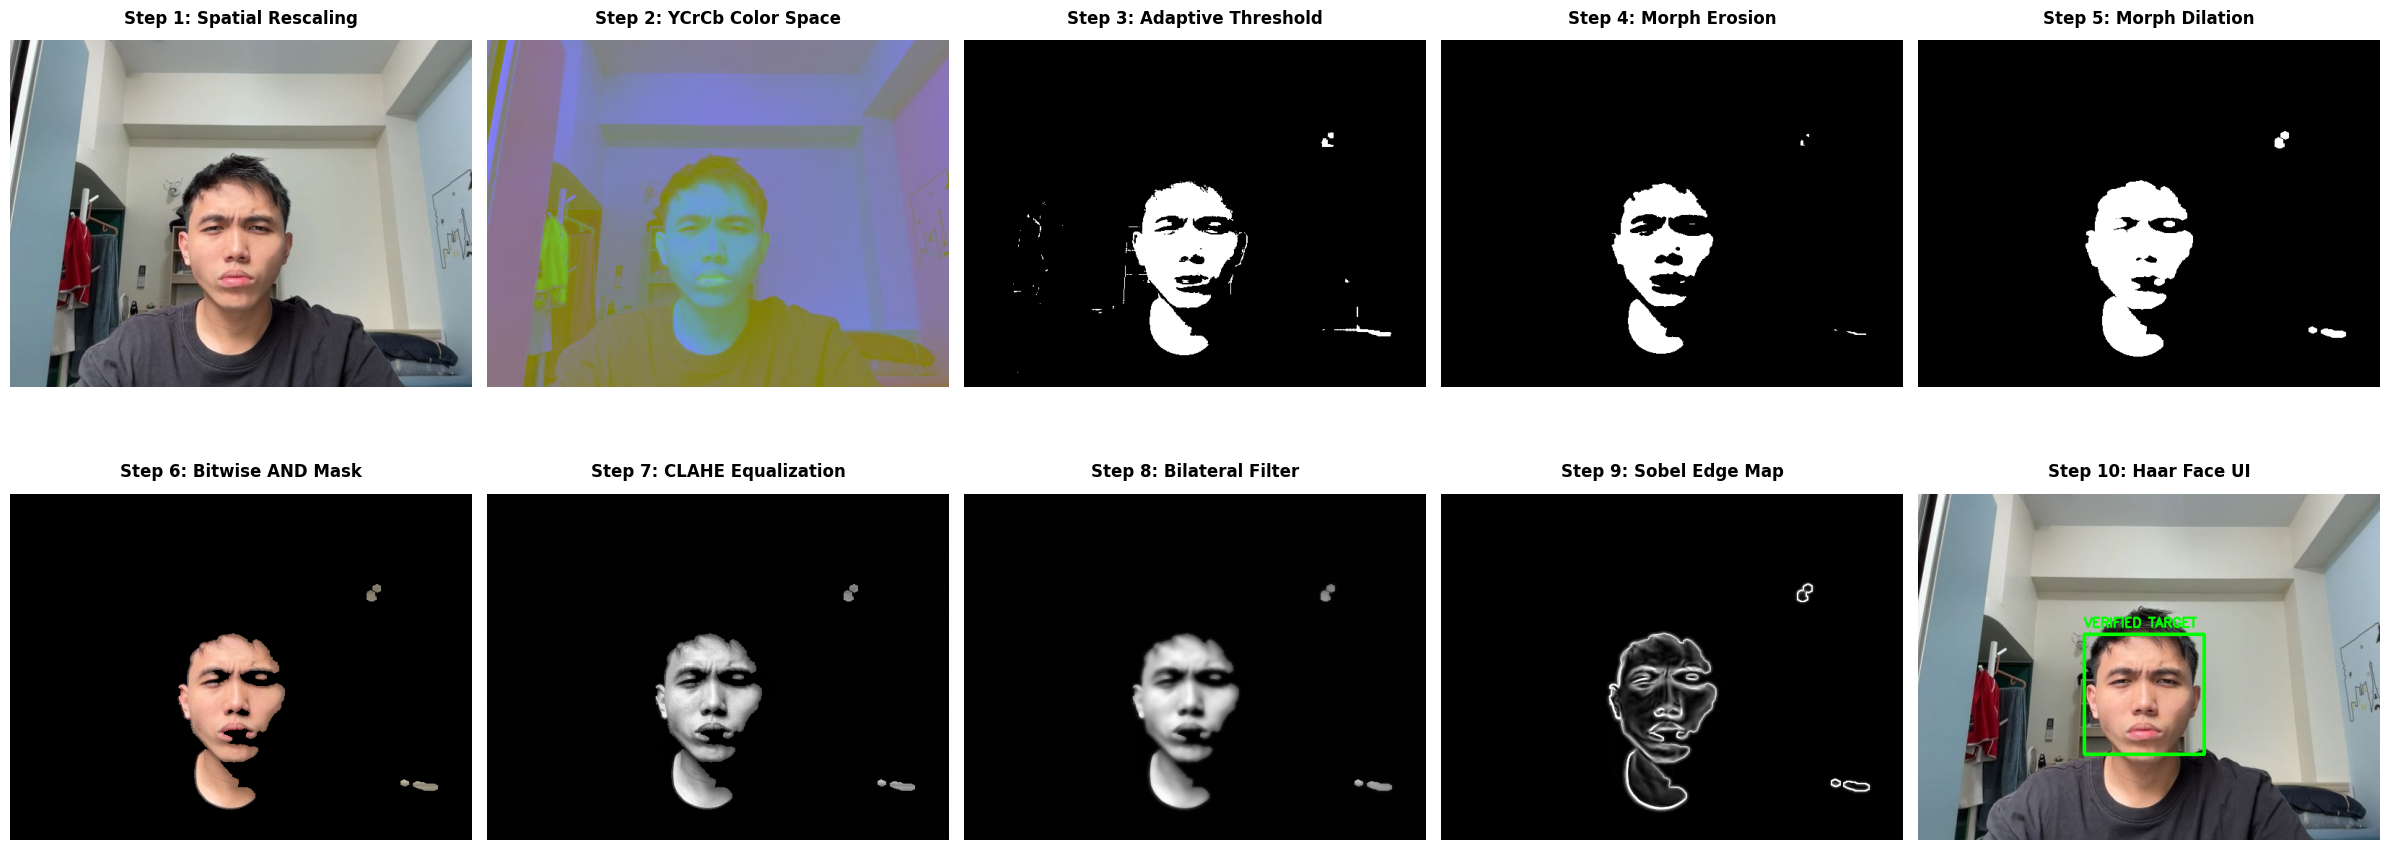


ACADEMIC EVALUATION ENGINE COMPLETE: 10 DISTINCT FEATURES DEMOED


In [ ]:
import cv2
import numpy as np
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# JAVASCRIPT WEBCAM FEED ACCESS STREAMER
# ---------------------------------------------------------------------
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      div.style.padding = '12px';
      div.style.background = '#1e1e1e';
      div.style.border = '2px solid #333';
      div.style.borderRadius = '8px';
      div.style.display = 'inline-block';

      const capture = document.createElement('button');
      capture.textContent = '📸 EXECUTE 2x5 ACADEMIC GRID PIPELINE';
      capture.style.background = '#00E676';
      capture.style.color = '#000';
      capture.style.fontWeight = 'bold';
      capture.style.padding = '12px 24px';
      capture.style.border = 'none';
      capture.style.borderRadius = '4px';
      capture.style.cursor = 'pointer';
      capture.style.display = 'block';
      capture.style.width = '100%';

      const video = document.createElement('video');
      video.style.display = 'block';
      video.style.width = '480px';

      div.appendChild(capture);
      div.appendChild(video);
      document.body.appendChild(div);

      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

def run_academic_grid_pipeline():
    try:
        img_path = take_photo()
    except Exception as err:
        print("Webcam access denied or unavailable. Please check browser permissions.")
        return

    # Load original raw input frame
    raw_frame = cv2.imread(img_path)
    print("\n... Target Frame Logged. Compiling 10-Step Academic Grid ...\n")

    # --------------------------------------------------------------------------
    # PROCESSING PIPELINE STEPS
    # --------------------------------------------------------------------------

    # Step 1: Spatial Rescaling (Matrix Resize + Mirror Flip for natural UI)
    f1_resized = cv2.resize(raw_frame, (640, 480), interpolation=cv2.INTER_AREA)
    f1_resized = cv2.flip(f1_resized, 1)

    # Step 2: Color Space Conversion (YCrCb)
    f2_ycrcb = cv2.cvtColor(f1_resized, cv2.COLOR_BGR2YCrCb)

    # Step 3: Adaptive Thresholding (Otsu's Binarization)
    lower_skin = np.array([0, 133, 77], dtype=np.uint8)
    upper_skin = np.array([255, 173, 127], dtype=np.uint8)
    skin_mask = cv2.inRange(f2_ycrcb, lower_skin, upper_skin)

    y_channel = f2_ycrcb[:, :, 0]
    _, otsu_mask = cv2.threshold(y_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    f3_combined_mask = cv2.bitwise_and(skin_mask, otsu_mask)

    # Morphological setup
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

    # Step 4: Morphological Filtering (Erosion)
    f4_eroded = cv2.erode(f3_combined_mask, kernel, iterations=1)

    # Step 5: Morphological Filtering (Dilation)
    f5_dilated = cv2.dilate(f4_eroded, kernel, iterations=2)

    # Step 6: Bitwise Logical Operation (AND Masking)
    f6_masked = cv2.bitwise_and(f1_resized, f1_resized, mask=f5_dilated)

    # Step 7: Contrast Equalization (CLAHE)
    gray_asset = cv2.cvtColor(f6_masked, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    f7_equalized = clahe.apply(gray_asset)

    # Step 8: Spatial Filtering (Bilateral Edge-Preserving Filter)
    f8_filtered = cv2.bilateralFilter(f7_equalized, d=9, sigmaColor=75, sigmaSpace=75)

    # Step 9: Edge Detection (Sobel Gradients)
    sobel_x = cv2.Sobel(f8_filtered, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(f8_filtered, cv2.CV_64F, 0, 1, ksize=3)
    sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    f9_sobel_edges = np.uint8(np.clip(sobel_magnitude, 0, 255))

    # Step 10: Feature Matching (Haar Cascade Spatial Classification)
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    faces = face_cascade.detectMultiScale(f8_filtered, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    f10_output_ui = f1_resized.copy()
    for (x, y, w, h) in faces:
        cv2.rectangle(f10_output_ui, (x, y), (x+w, y+h), (0, 255, 0), 3)
        cv2.putText(f10_output_ui, "VERIFIED TARGET", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # --------------------------------------------------------------------------
    # RENDER 2x5 MULTI-PLOT GRID OVERLAY
    # --------------------------------------------------------------------------
    fig, axes = plt.subplots(2, 5, figsize=(24, 10))

    # Organize data list sequentially (matrix, title)
    # OpenCV uses BGR, Matplotlib uses RGB. We must fix color formats for display!
    steps_data = [
        (cv2.cvtColor(f1_resized, cv2.COLOR_BGR2RGB), "Step 1: Spatial Rescaling"),
        (cv2.cvtColor(f2_ycrcb, cv2.COLOR_BGR2RGB), "Step 2: YCrCb Color Space"),
        (f3_combined_mask, "Step 3: Adaptive Threshold"),
        (f4_eroded, "Step 4: Morph Erosion"),
        (f5_dilated, "Step 5: Morph Dilation"),
        (cv2.cvtColor(f6_masked, cv2.COLOR_BGR2RGB), "Step 6: Bitwise AND Mask"),
        (f7_equalized, "Step 7: CLAHE Equalization"),
        (f8_filtered, "Step 8: Bilateral Filter"),
        (f9_sobel_edges, "Step 9: Sobel Edge Map"),
        (cv2.cvtColor(f10_output_ui, cv2.COLOR_BGR2RGB), "Step 10: Haar Face UI")
    ]

    for idx, (img_matrix, title_text) in enumerate(steps_data):
        row = idx // 5  # First 5 go to row 0, next 5 go to row 1
        col = idx % 5   # Determines column placement (0 to 4)
        ax = axes[row, col]

        # Check if matrix is 2D grayscale or 3D color channels
        if len(img_matrix.shape) == 2:
            ax.imshow(img_matrix, cmap='gray')
        else:
            ax.imshow(img_matrix)

        ax.set_title(title_text, fontsize=12, fontweight='bold', pad=12)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    print("\n" + "="*60)
    print("ACADEMIC EVALUATION ENGINE COMPLETE: 10 DISTINCT FEATURES DEMOED")
    print("="*60)

# Execute the final grid layout
run_academic_grid_pipeline()

<IPython.core.display.Javascript object>


... Target Frame Logged. Compiling 10-Step Academic Grid ...



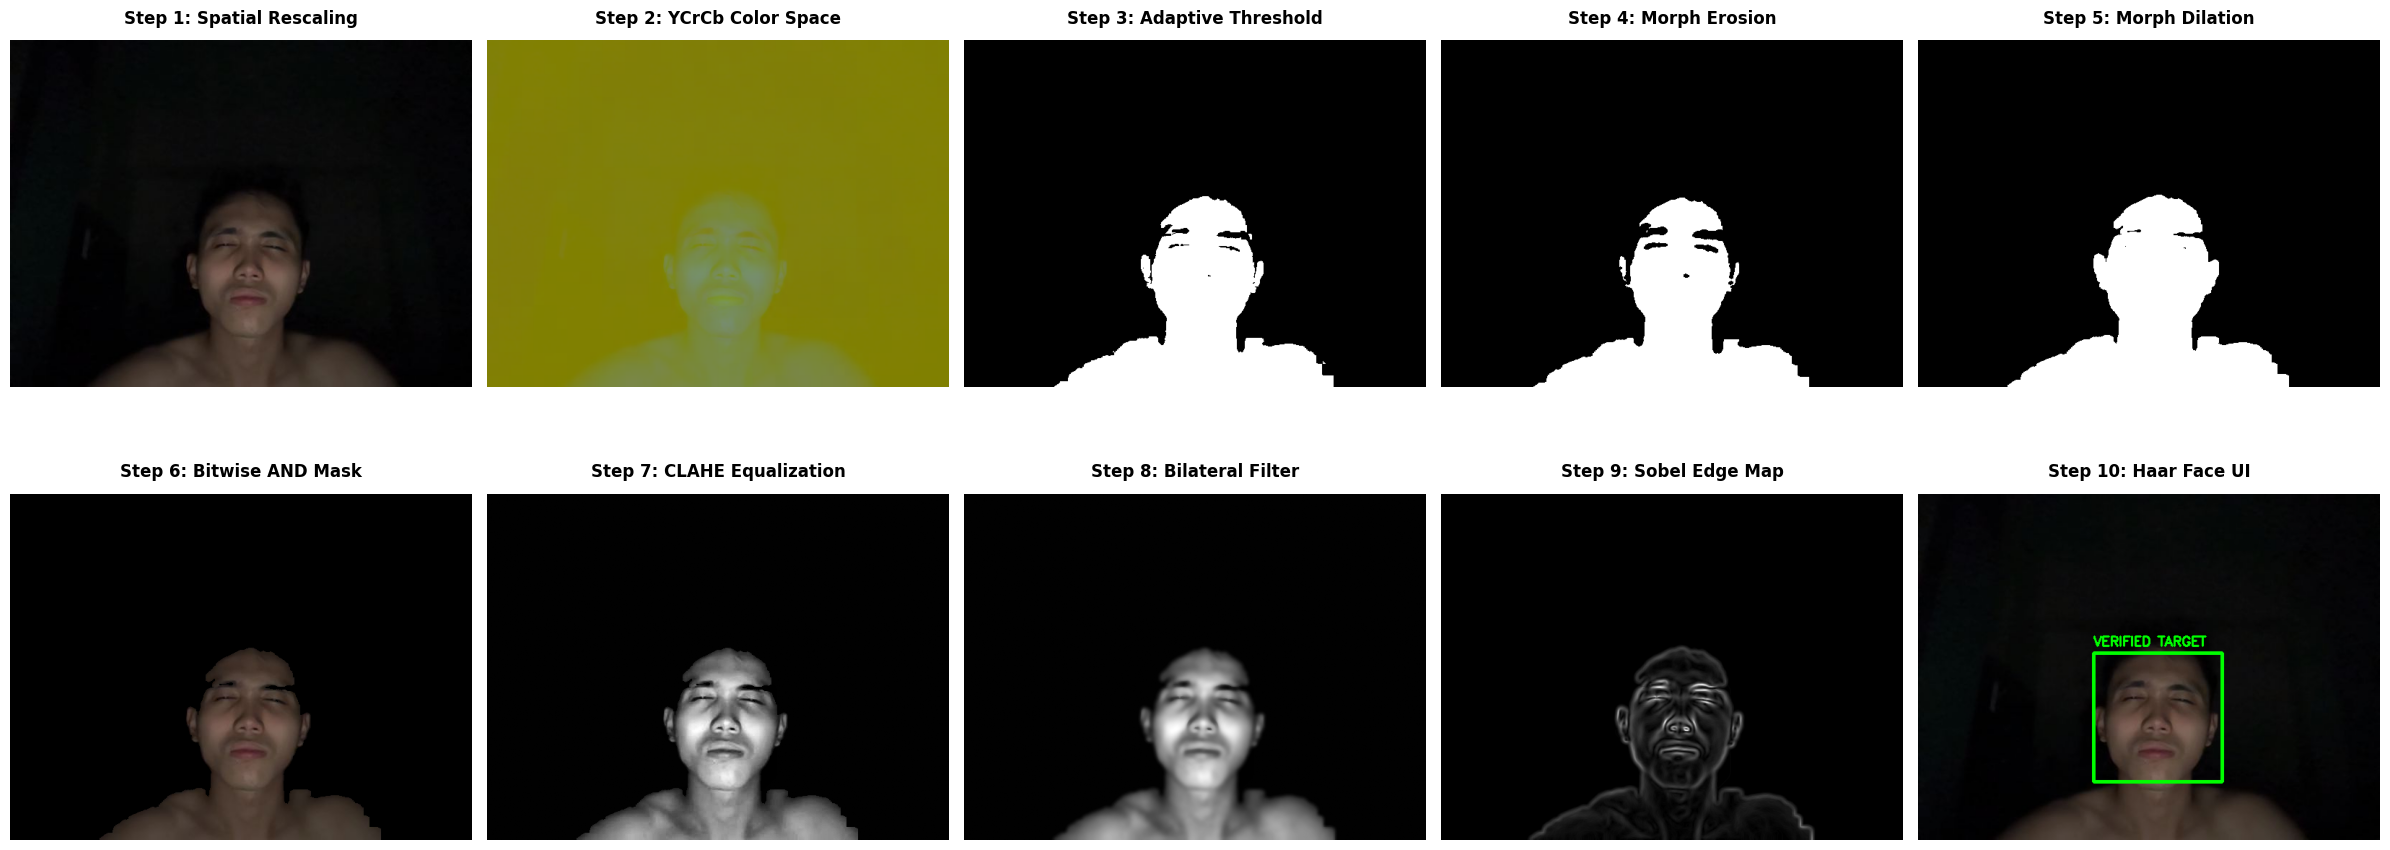


ACADEMIC EVALUATION ENGINE COMPLETE: 10 DISTINCT FEATURES DEMOED


In [ ]:
import cv2
import numpy as np
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# JAVASCRIPT WEBCAM FEED ACCESS STREAMER
# ---------------------------------------------------------------------
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      div.style.padding = '12px';
      div.style.background = '#1e1e1e';
      div.style.border = '2px solid #333';
      div.style.borderRadius = '8px';
      div.style.display = 'inline-block';

      const capture = document.createElement('button');
      capture.textContent = '📸 EXECUTE 2x5 ACADEMIC GRID PIPELINE';
      capture.style.background = '#00E676';
      capture.style.color = '#000';
      capture.style.fontWeight = 'bold';
      capture.style.padding = '12px 24px';
      capture.style.border = 'none';
      capture.style.borderRadius = '4px';
      capture.style.cursor = 'pointer';
      capture.style.display = 'block';
      capture.style.width = '100%';

      const video = document.createElement('video');
      video.style.display = 'block';
      video.style.width = '480px';

      div.appendChild(capture);
      div.appendChild(video);
      document.body.appendChild(div);

      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

def run_academic_grid_pipeline():
    try:
        img_path = take_photo()
    except Exception as err:
        print("Webcam access denied or unavailable. Please check browser permissions.")
        return

    # Load original raw input frame
    raw_frame = cv2.imread(img_path)
    print("\n... Target Frame Logged. Compiling 10-Step Academic Grid ...\n")

    # --------------------------------------------------------------------------
    # PROCESSING PIPELINE STEPS
    # --------------------------------------------------------------------------

    # Step 1: Spatial Rescaling (Matrix Resize + Mirror Flip for natural UI)
    f1_resized = cv2.resize(raw_frame, (640, 480), interpolation=cv2.INTER_AREA)
    f1_resized = cv2.flip(f1_resized, 1)

    # Step 2: Color Space Conversion (YCrCb)
    f2_ycrcb = cv2.cvtColor(f1_resized, cv2.COLOR_BGR2YCrCb)

    # Step 3: Adaptive Thresholding (Otsu's Binarization)
    lower_skin = np.array([0, 133, 77], dtype=np.uint8)
    upper_skin = np.array([255, 173, 127], dtype=np.uint8)
    skin_mask = cv2.inRange(f2_ycrcb, lower_skin, upper_skin)

    y_channel = f2_ycrcb[:, :, 0]
    _, otsu_mask = cv2.threshold(y_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    f3_combined_mask = cv2.bitwise_and(skin_mask, otsu_mask)

    # Morphological setup
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

    # Step 4: Morphological Filtering (Erosion)
    f4_eroded = cv2.erode(f3_combined_mask, kernel, iterations=1)

    # Step 5: Morphological Filtering (Dilation)
    f5_dilated = cv2.dilate(f4_eroded, kernel, iterations=2)

    # Step 6: Bitwise Logical Operation (AND Masking)
    f6_masked = cv2.bitwise_and(f1_resized, f1_resized, mask=f5_dilated)

    # Step 7: Contrast Equalization (CLAHE)
    gray_asset = cv2.cvtColor(f6_masked, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    f7_equalized = clahe.apply(gray_asset)

    # Step 8: Spatial Filtering (Bilateral Edge-Preserving Filter)
    f8_filtered = cv2.bilateralFilter(f7_equalized, d=9, sigmaColor=75, sigmaSpace=75)

    # Step 9: Edge Detection (Sobel Gradients)
    sobel_x = cv2.Sobel(f8_filtered, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(f8_filtered, cv2.CV_64F, 0, 1, ksize=3)
    sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    f9_sobel_edges = np.uint8(np.clip(sobel_magnitude, 0, 255))

    # Step 10: Feature Matching (Haar Cascade Spatial Classification)
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    faces = face_cascade.detectMultiScale(f8_filtered, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    f10_output_ui = f1_resized.copy()
    for (x, y, w, h) in faces:
        cv2.rectangle(f10_output_ui, (x, y), (x+w, y+h), (0, 255, 0), 3)
        cv2.putText(f10_output_ui, "VERIFIED TARGET", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # --------------------------------------------------------------------------
    # RENDER 2x5 MULTI-PLOT GRID OVERLAY
    # --------------------------------------------------------------------------
    fig, axes = plt.subplots(2, 5, figsize=(24, 10))

    # Organize data list sequentially (matrix, title)
    # OpenCV uses BGR, Matplotlib uses RGB. We must fix color formats for display!
    steps_data = [
        (cv2.cvtColor(f1_resized, cv2.COLOR_BGR2RGB), "Step 1: Spatial Rescaling"),
        (cv2.cvtColor(f2_ycrcb, cv2.COLOR_BGR2RGB), "Step 2: YCrCb Color Space"),
        (f3_combined_mask, "Step 3: Adaptive Threshold"),
        (f4_eroded, "Step 4: Morph Erosion"),
        (f5_dilated, "Step 5: Morph Dilation"),
        (cv2.cvtColor(f6_masked, cv2.COLOR_BGR2RGB), "Step 6: Bitwise AND Mask"),
        (f7_equalized, "Step 7: CLAHE Equalization"),
        (f8_filtered, "Step 8: Bilateral Filter"),
        (f9_sobel_edges, "Step 9: Sobel Edge Map"),
        (cv2.cvtColor(f10_output_ui, cv2.COLOR_BGR2RGB), "Step 10: Haar Face UI")
    ]

    for idx, (img_matrix, title_text) in enumerate(steps_data):
        row = idx // 5  # First 5 go to row 0, next 5 go to row 1
        col = idx % 5   # Determines column placement (0 to 4)
        ax = axes[row, col]

        # Check if matrix is 2D grayscale or 3D color channels
        if len(img_matrix.shape) == 2:
            ax.imshow(img_matrix, cmap='gray')
        else:
            ax.imshow(img_matrix)

        ax.set_title(title_text, fontsize=12, fontweight='bold', pad=12)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    print("\n" + "="*60)
    print("ACADEMIC EVALUATION ENGINE COMPLETE: 10 DISTINCT FEATURES DEMOED")
    print("="*60)

# Execute the final grid layout
run_academic_grid_pipeline()

<IPython.core.display.Javascript object>


... Target Frame Logged. Compiling 10-Step Academic Grid ...



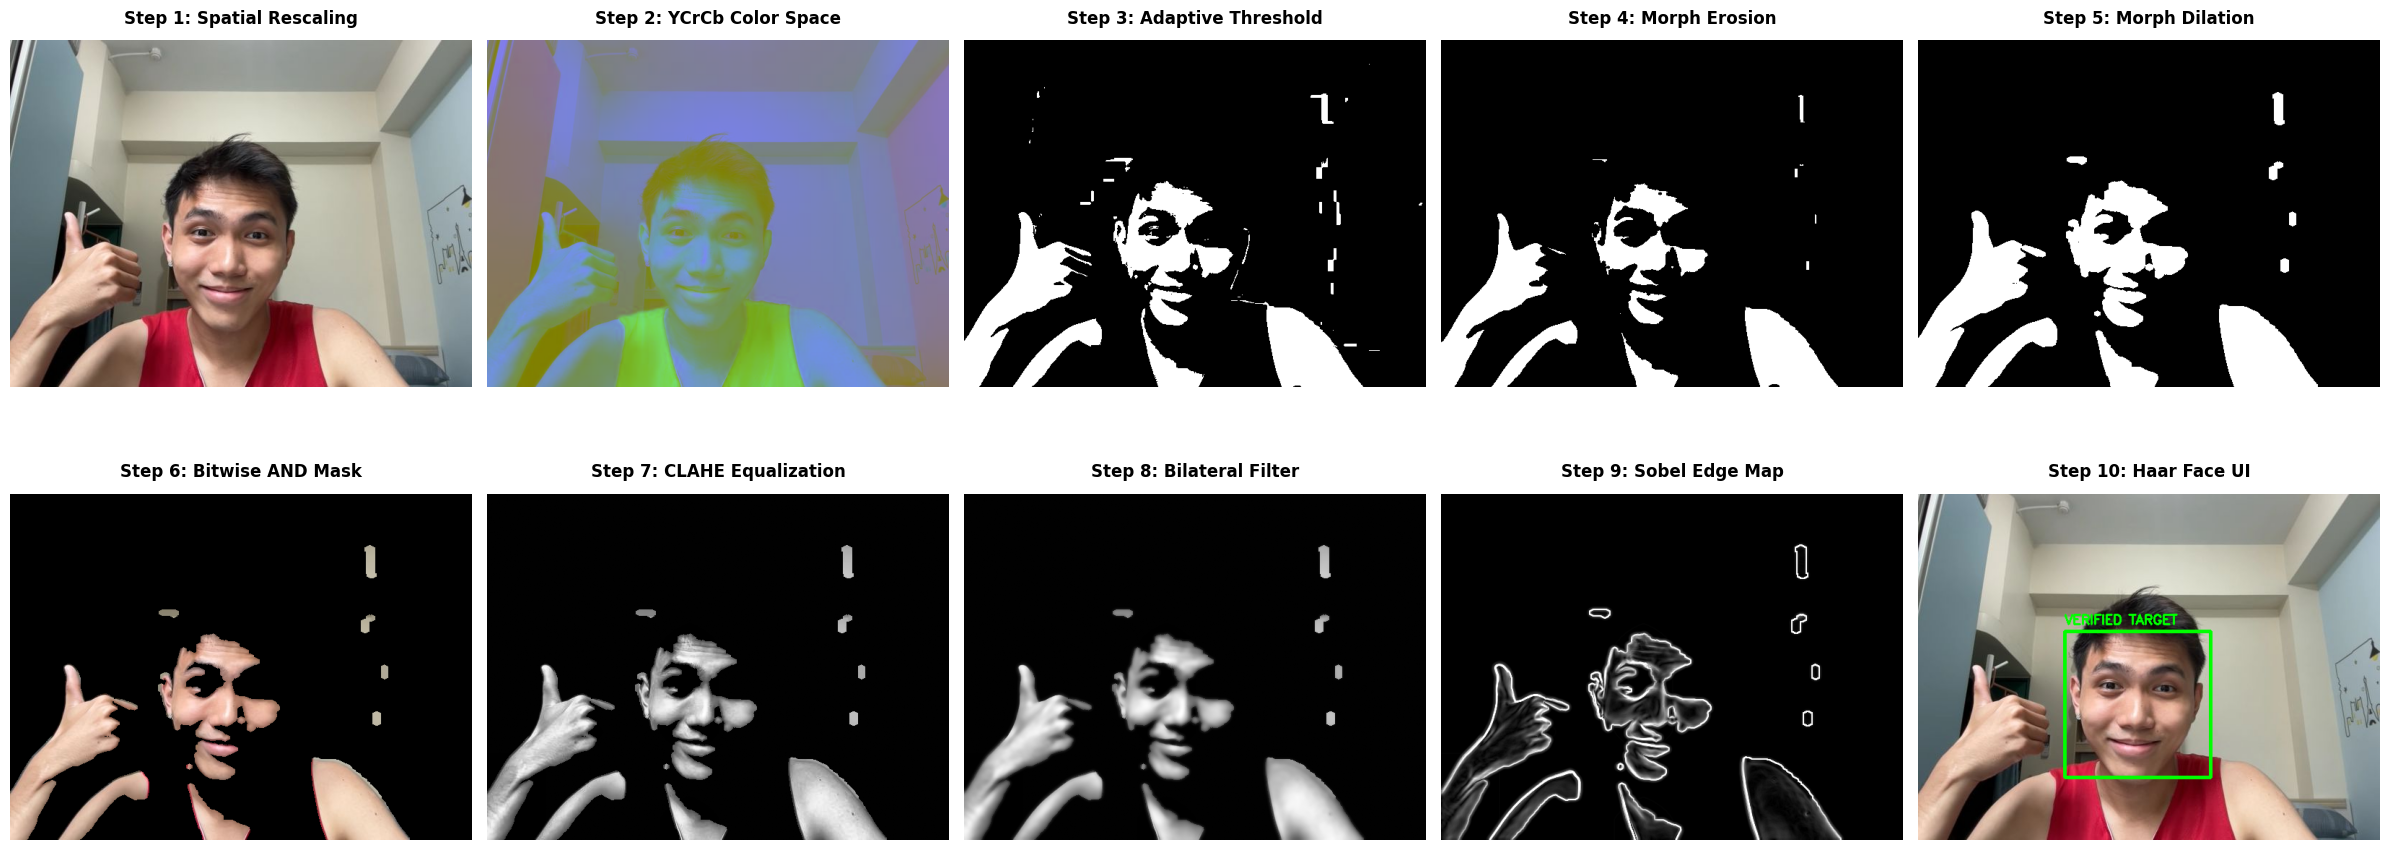


ACADEMIC EVALUATION ENGINE COMPLETE: 10 DISTINCT FEATURES DEMOED


In [9]:
import cv2
import numpy as np
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# JAVASCRIPT WEBCAM FEED ACCESS STREAMER
# ---------------------------------------------------------------------
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      div.style.padding = '12px';
      div.style.background = '#1e1e1e';
      div.style.border = '2px solid #333';
      div.style.borderRadius = '8px';
      div.style.display = 'inline-block';

      const capture = document.createElement('button');
      capture.textContent = '📸 EXECUTE 2x5 ACADEMIC GRID PIPELINE';
      capture.style.background = '#00E676';
      capture.style.color = '#000';
      capture.style.fontWeight = 'bold';
      capture.style.padding = '12px 24px';
      capture.style.border = 'none';
      capture.style.borderRadius = '4px';
      capture.style.cursor = 'pointer';
      capture.style.display = 'block';
      capture.style.width = '100%';

      const video = document.createElement('video');
      video.style.display = 'block';
      video.style.width = '480px';

      div.appendChild(capture);
      div.appendChild(video);
      document.body.appendChild(div);

      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

def run_academic_grid_pipeline():
    try:
        img_path = take_photo()
    except Exception as err:
        print("Webcam access denied or unavailable. Please check browser permissions.")
        return

    # Load original raw input frame
    raw_frame = cv2.imread(img_path)
    print("\n... Target Frame Logged. Compiling 10-Step Academic Grid ...\n")

    # --------------------------------------------------------------------------
    # PROCESSING PIPELINE STEPS
    # --------------------------------------------------------------------------

    # Step 1: Spatial Rescaling (Matrix Resize + Mirror Flip for natural UI)
    f1_resized = cv2.resize(raw_frame, (640, 480), interpolation=cv2.INTER_AREA)
    f1_resized = cv2.flip(f1_resized, 1)

    # Step 2: Color Space Conversion (YCrCb)
    f2_ycrcb = cv2.cvtColor(f1_resized, cv2.COLOR_BGR2YCrCb)

    # Step 3: Adaptive Thresholding (Otsu's Binarization)
    lower_skin = np.array([0, 133, 77], dtype=np.uint8)
    upper_skin = np.array([255, 173, 127], dtype=np.uint8)
    skin_mask = cv2.inRange(f2_ycrcb, lower_skin, upper_skin)

    y_channel = f2_ycrcb[:, :, 0]
    _, otsu_mask = cv2.threshold(y_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    f3_combined_mask = cv2.bitwise_and(skin_mask, otsu_mask)

    # Morphological setup
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

    # Step 4: Morphological Filtering (Erosion)
    f4_eroded = cv2.erode(f3_combined_mask, kernel, iterations=1)

    # Step 5: Morphological Filtering (Dilation)
    f5_dilated = cv2.dilate(f4_eroded, kernel, iterations=2)

    # Step 6: Bitwise Logical Operation (AND Masking)
    f6_masked = cv2.bitwise_and(f1_resized, f1_resized, mask=f5_dilated)

    # Step 7: Contrast Equalization (CLAHE)
    gray_asset = cv2.cvtColor(f6_masked, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    f7_equalized = clahe.apply(gray_asset)

    # Step 8: Spatial Filtering (Bilateral Edge-Preserving Filter)
    f8_filtered = cv2.bilateralFilter(f7_equalized, d=9, sigmaColor=75, sigmaSpace=75)

    # Step 9: Edge Detection (Sobel Gradients)
    sobel_x = cv2.Sobel(f8_filtered, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(f8_filtered, cv2.CV_64F, 0, 1, ksize=3)
    sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    f9_sobel_edges = np.uint8(np.clip(sobel_magnitude, 0, 255))

    # Step 10: Feature Matching (Haar Cascade Spatial Classification)
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    faces = face_cascade.detectMultiScale(f8_filtered, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    f10_output_ui = f1_resized.copy()
    for (x, y, w, h) in faces:
        cv2.rectangle(f10_output_ui, (x, y), (x+w, y+h), (0, 255, 0), 3)
        cv2.putText(f10_output_ui, "VERIFIED TARGET", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # --------------------------------------------------------------------------
    # RENDER 2x5 MULTI-PLOT GRID OVERLAY
    # --------------------------------------------------------------------------
    fig, axes = plt.subplots(2, 5, figsize=(24, 10))

    # Organize data list sequentially (matrix, title)
    # OpenCV uses BGR, Matplotlib uses RGB. We must fix color formats for display!
    steps_data = [
        (cv2.cvtColor(f1_resized, cv2.COLOR_BGR2RGB), "Step 1: Spatial Rescaling"),
        (cv2.cvtColor(f2_ycrcb, cv2.COLOR_BGR2RGB), "Step 2: YCrCb Color Space"),
        (f3_combined_mask, "Step 3: Adaptive Threshold"),
        (f4_eroded, "Step 4: Morph Erosion"),
        (f5_dilated, "Step 5: Morph Dilation"),
        (cv2.cvtColor(f6_masked, cv2.COLOR_BGR2RGB), "Step 6: Bitwise AND Mask"),
        (f7_equalized, "Step 7: CLAHE Equalization"),
        (f8_filtered, "Step 8: Bilateral Filter"),
        (f9_sobel_edges, "Step 9: Sobel Edge Map"),
        (cv2.cvtColor(f10_output_ui, cv2.COLOR_BGR2RGB), "Step 10: Haar Face UI")
    ]

    for idx, (img_matrix, title_text) in enumerate(steps_data):
        row = idx // 5  # First 5 go to row 0, next 5 go to row 1
        col = idx % 5   # Determines column placement (0 to 4)
        ax = axes[row, col]

        # Check if matrix is 2D grayscale or 3D color channels
        if len(img_matrix.shape) == 2:
            ax.imshow(img_matrix, cmap='gray')
        else:
            ax.imshow(img_matrix)

        ax.set_title(title_text, fontsize=12, fontweight='bold', pad=12)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    print("\n" + "="*60)
    print("ACADEMIC EVALUATION ENGINE COMPLETE: 10 DISTINCT FEATURES DEMOED")
    print("="*60)

# Execute the final grid layout
run_academic_grid_pipeline()